In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [2]:
data = pd.read_excel('../data.xlsx')
data.columns = [col.split(' (')[0] if ":" in col else col for col in data.columns]
data['Normal fertilization'] = data['Normal fertilization'].replace({0: 'abnormal', 1: 'normal'})

interpret_result = pd.read_csv('./interpret_result.csv')
predict_result = pd.read_csv('./predictions.csv')
predict_result['targets'] = predict_result['targets'].replace({0: 'normal', 1: 'abnormal'})

interpret_result.columns = data.drop(columns=["ID", "Normal fertilization"]).columns
result = pd.concat([predict_result, interpret_result], axis=1)
result


,predictions,targets,Patient age,Partner age,Previous IVF cycles,Infertility type,Male factors cause infertility,Female factors cause infertility,Years of infertility,Body Mass Index (BMI),...,IM (Immotile) sperm count before semen optimization treatment,Total sperm count before semen optimization treatment (x10^6),Volume after semen optimization treatment,Concentration after semen optimization treatment,PR sperm count after semen optimization treatment,NP sperm count after semen optimization treatment,IM sperm count after semen optimization treatment,Number of oocyte for IVF,Number of oocyte for ICSI,Number of MII oocyte for ICSI
0,0.074489,normal,0.072651,0.072651,0.016778,0.016778,0.016778,0.016778,0.081541,0.142475,...,0.017475,0.057376,0.007746,-0.287740,0.057851,0.081541,0.081541,-0.027672,0.000000,0.000000
1,0.049074,normal,0.060204,0.048895,0.006326,0.000000,0.006326,0.000000,-0.046502,0.079233,...,0.000604,-0.002922,0.004167,-0.046502,-0.003286,-0.051918,0.075976,0.000000,-0.071911,-0.071911
2,0.357884,normal,0.141140,0.099781,0.016555,0.000000,0.016555,0.000000,0.016555,0.199709,...,-0.017117,NaN,0.008406,0.016555,0.000000,0.000000,-0.017117,0.000000,-0.156026,-0.156026
3,0.136964,normal,0.080710,0.062414,-0.034180,0.000000,0.000000,-0.034180,-0.034180,0.130657,...,0.036930,0.036089,0.007465,-0.258806,0.033833,-0.061641,0.017500,0.701076,0.000000,0.000000
4,0.173919,normal,0.115116,0.117835,-0.038464,0.000000,-0.038464,0.000000,0.091874,0.125398,...,0.036373,0.037658,0.008517,-0.031324,0.000000,0.000000,0.036373,0.000000,0.037605,0.037605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1228,0.250619,abnormal,0.026554,0.025417,-0.336876,0.000000,0.000000,0.007569,0.021044,0.042247,...,0.025419,0.063406,0.010057,0.013310,0.030292,0.013310,0.037108,0.000000,0.007569,0.007569
1229,0.071425,normal,0.070986,0.061700,0.008684,0.008684,0.000000,0.008684,0.008684,0.083941,...,0.012654,-0.018679,0.006879,-0.154754,0.002062,-0.127206,-0.127206,0.011183,0.000000,0.000000
1230,0.255810,normal,0.069509,0.066259,0.022376,0.000000,-0.031084,-0.031084,-0.031084,0.006126,...,0.064628,0.125340,0.015831,-0.034878,0.138233,0.123501,0.123501,-0.031084,0.000000,0.000000
1231,0.046477,normal,0.041030,0.030981,0.021634,0.021634,0.000000,0.021634,-0.061999,0.090270,...,0.015947,0.005203,0.012798,-0.174266,0.000437,-0.899569,-0.288753,0.091682,0.000000,0.000000


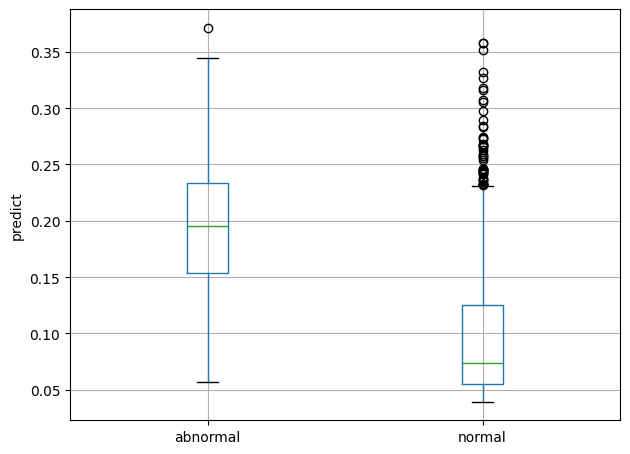

In [3]:
boxplot = result.boxplot(column=["predictions"], by="targets")

plt.suptitle('')
plt.title('')
plt.xlabel('')
plt.ylabel('predict')
plt.tight_layout()
plt.show()

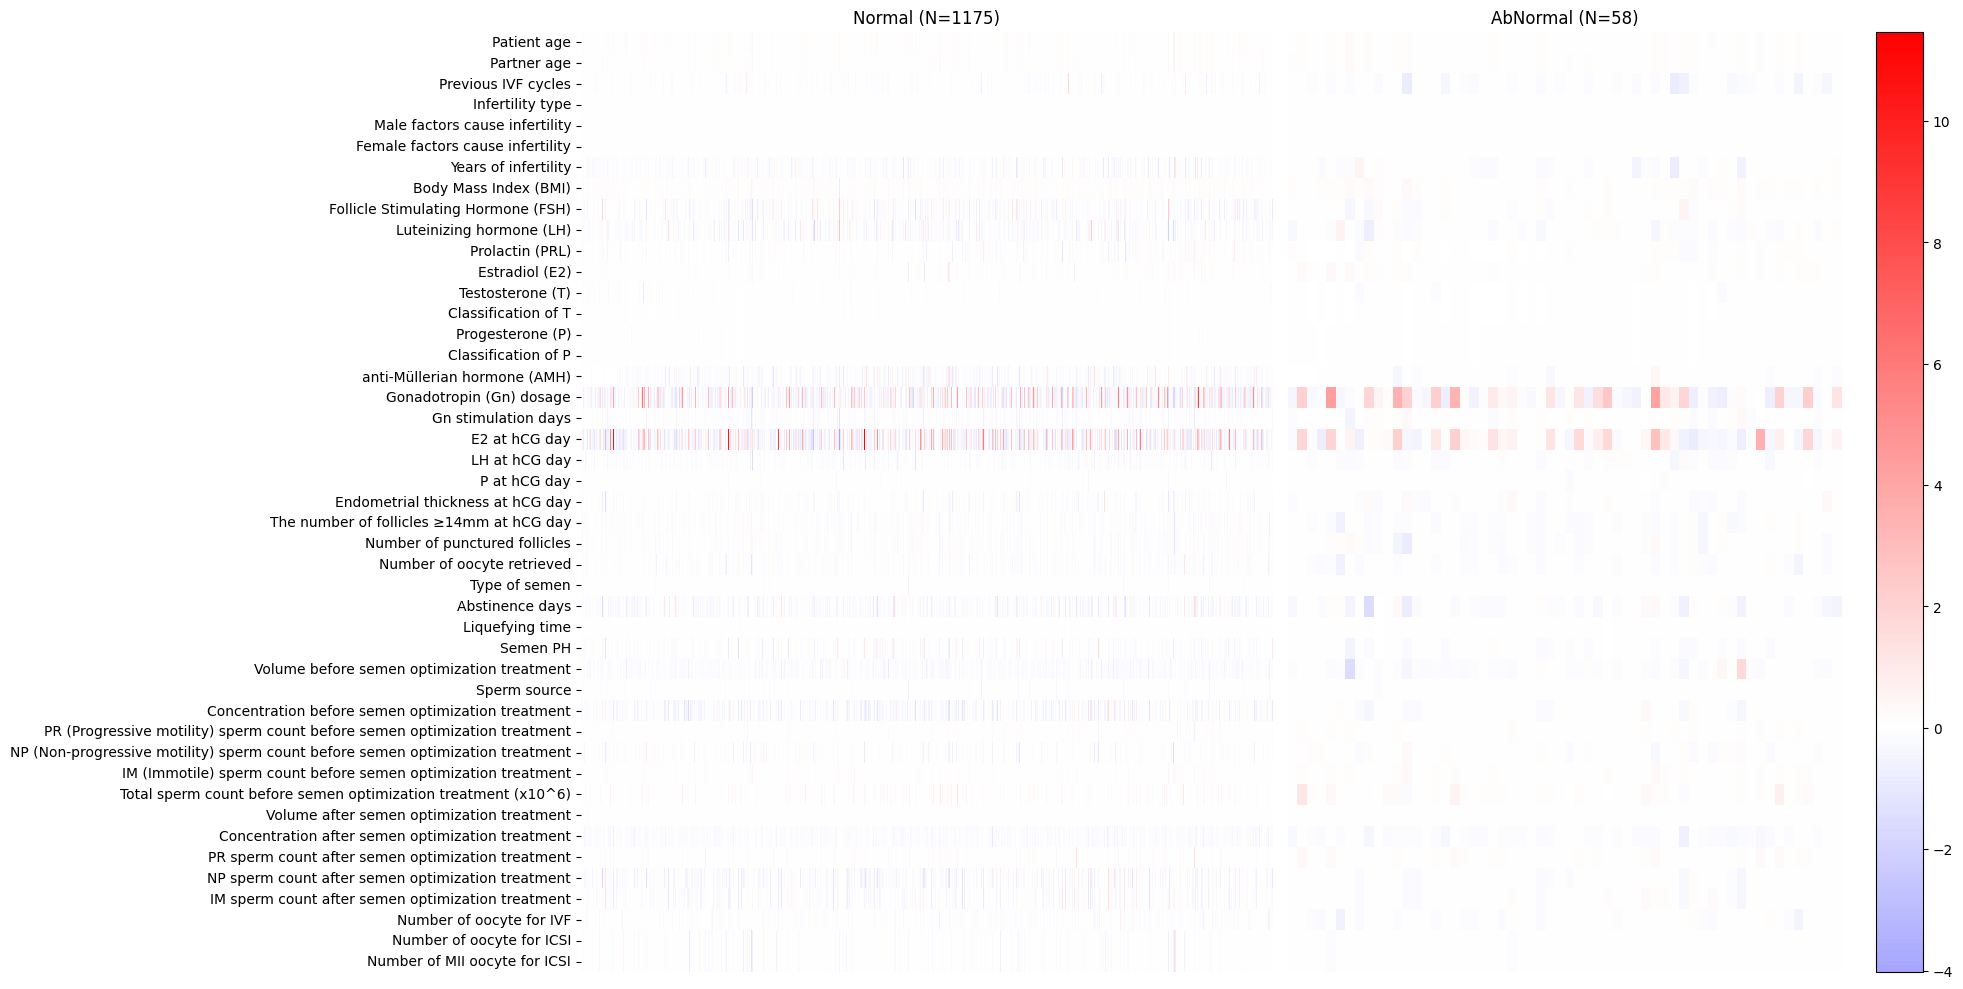

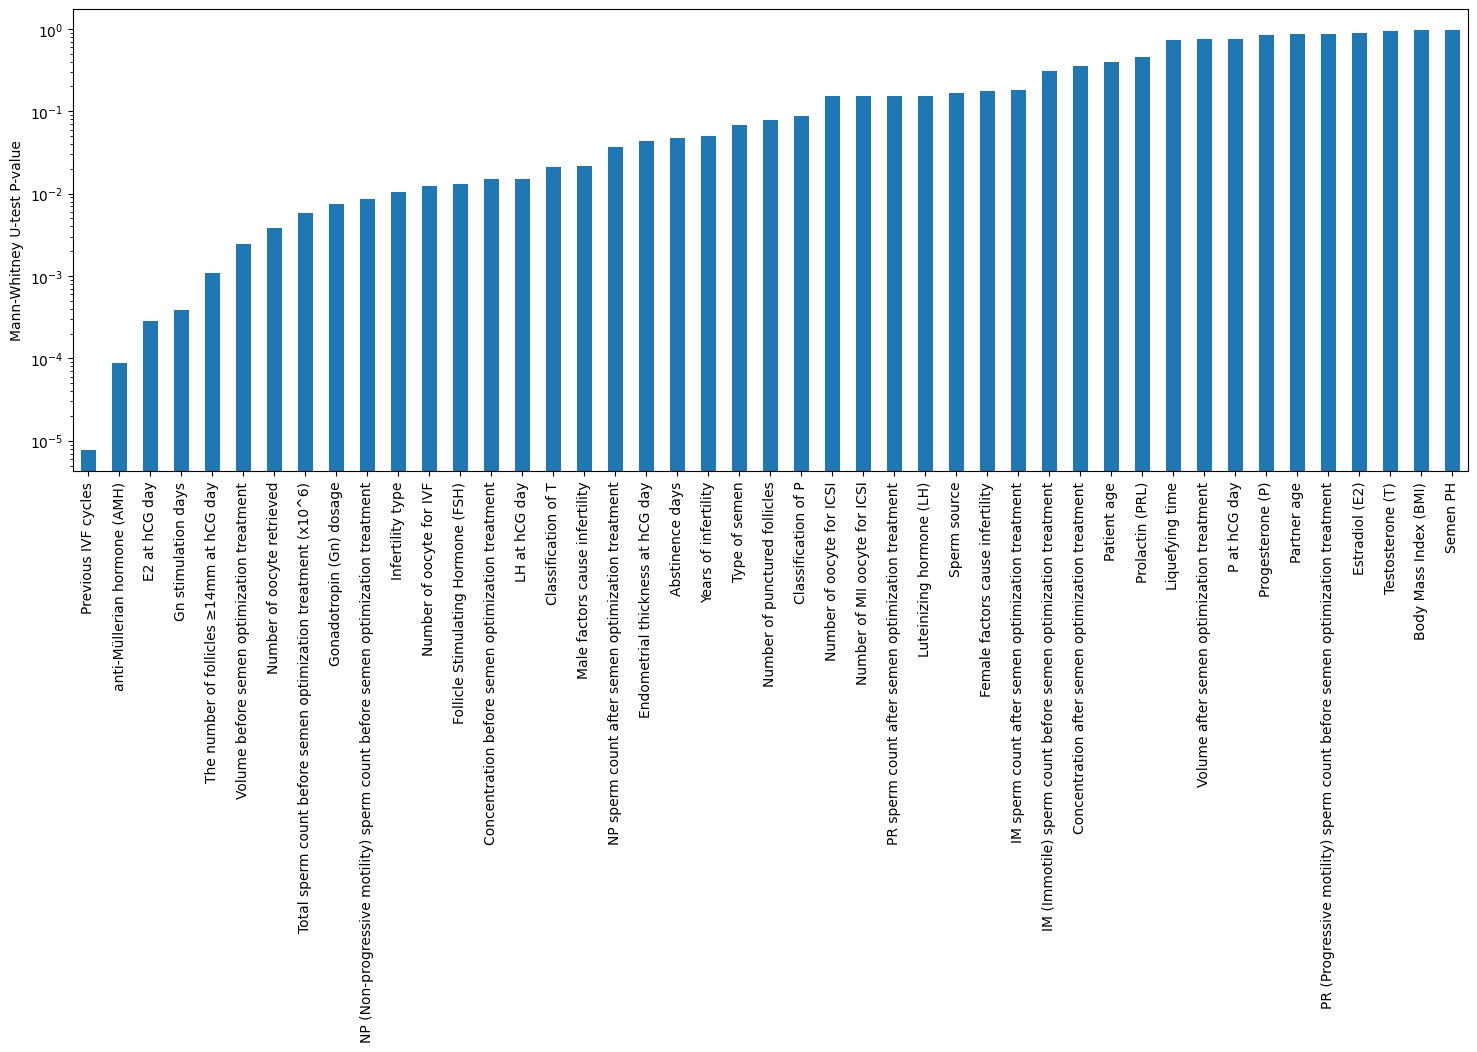

In [4]:
_normal = result[result["targets"] == 'normal'].drop(columns=predict_result.columns)
_abnormal = result[result["targets"] == 'abnormal'].drop(columns=predict_result.columns)

_vmin = min(_normal.min().min(), _abnormal.min().min())
_vmax = max(_normal.max().max(), _abnormal.max().max())
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
sns.heatmap(_normal.T, cmap='bwr', center=0, ax=axes[0], cbar=False, vmin=_vmin, vmax=_vmax)
axes[0].set_title('Normal (N={})'.format(_normal.shape[0]))
axes[0].set_xlabel('')
axes[0].set_xticks([])
sns.heatmap(_abnormal.T, cmap='bwr', center=0, ax=axes[1], cbar=False, vmin=_vmin, vmax=_vmax)
axes[1].set_title('AbNormal (N={})'.format(_abnormal.shape[0]))
axes[1].set_xlabel('')
axes[1].set_xticks([])
axes[1].set_yticks([])

fig.colorbar(axes[1].collections[0])
plt.tight_layout()
plt.show()

test_result = {}
for column in _normal.columns:
    _normal_clean = _normal[column][~np.isnan(_normal[column])]
    _abnormal_clean = _abnormal[column][~np.isnan(_abnormal[column])]
    u_stat, u_pvalue = mannwhitneyu(_normal_clean, _abnormal_clean, alternative='two-sided')
    
    test_result[column] = [u_pvalue]
test_result = pd.DataFrame(test_result)

ax = test_result.T.sort_values(by=0).plot(kind='bar', figsize=(18, 6), logy=True, legend=False)
plt.ylabel("Mann-Whitney U-test P-value")
plt.show()


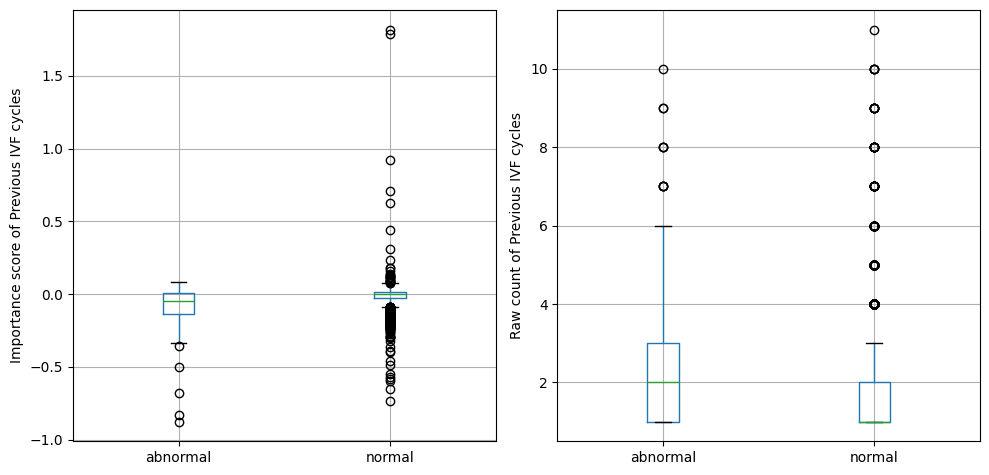

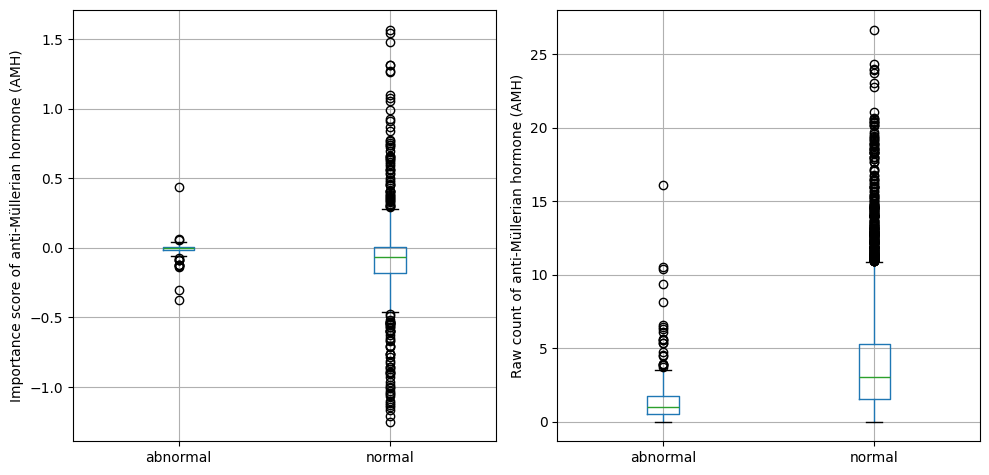

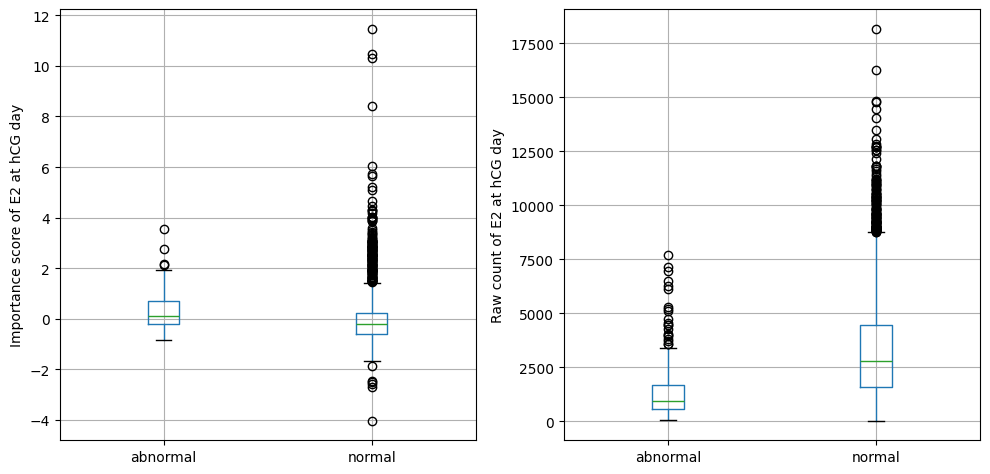

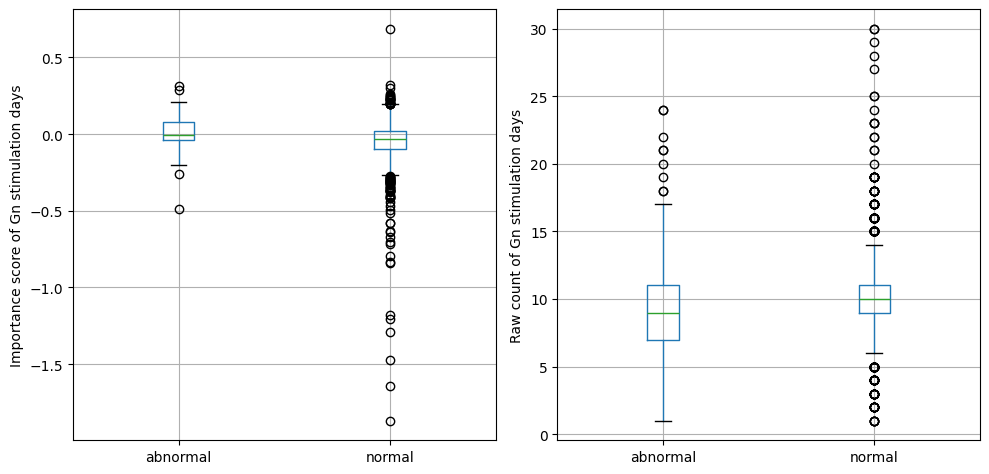

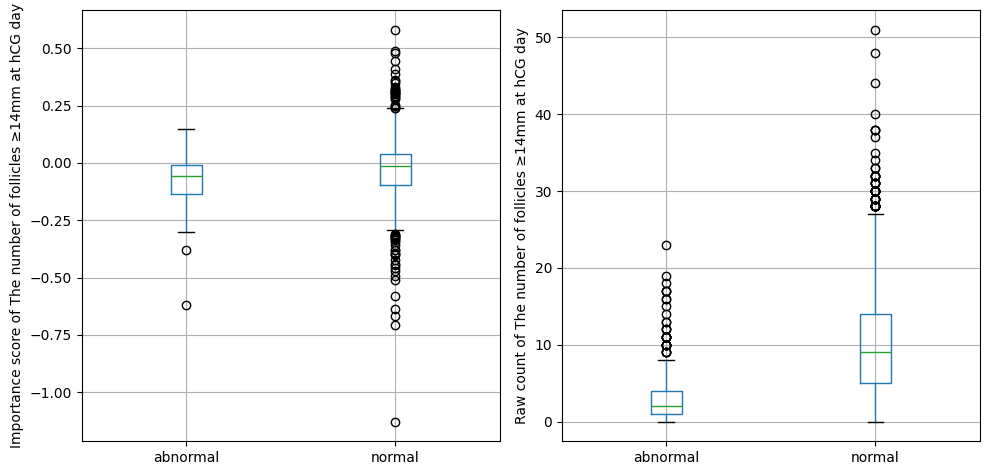

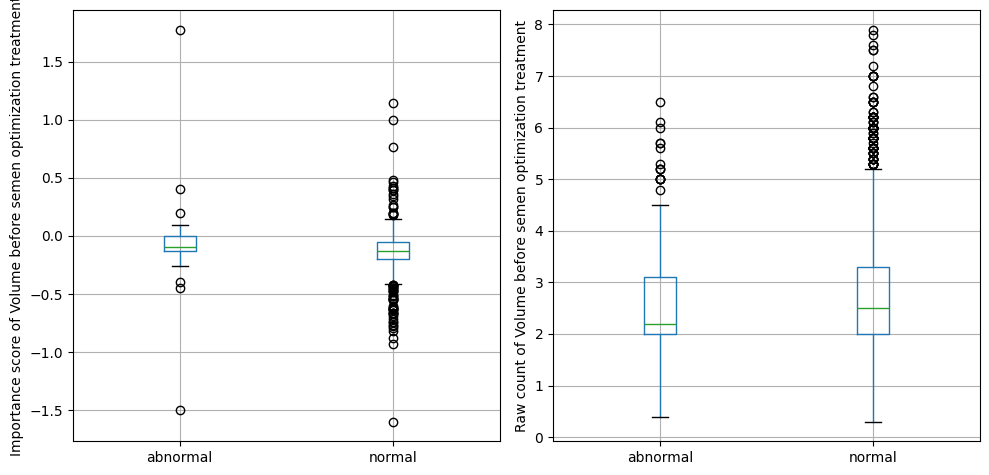

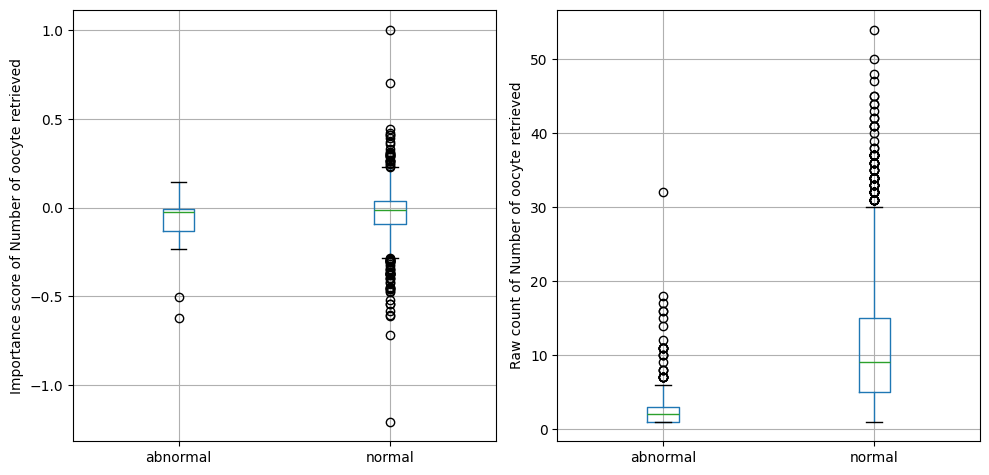

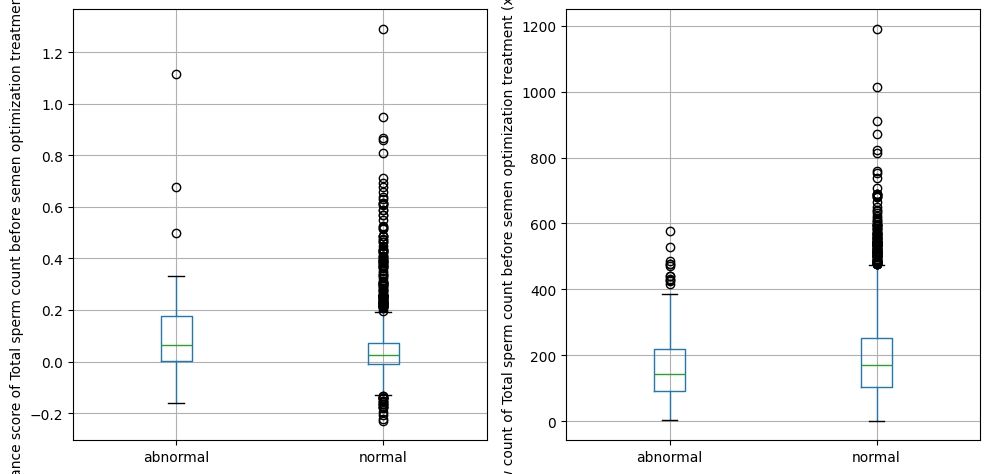

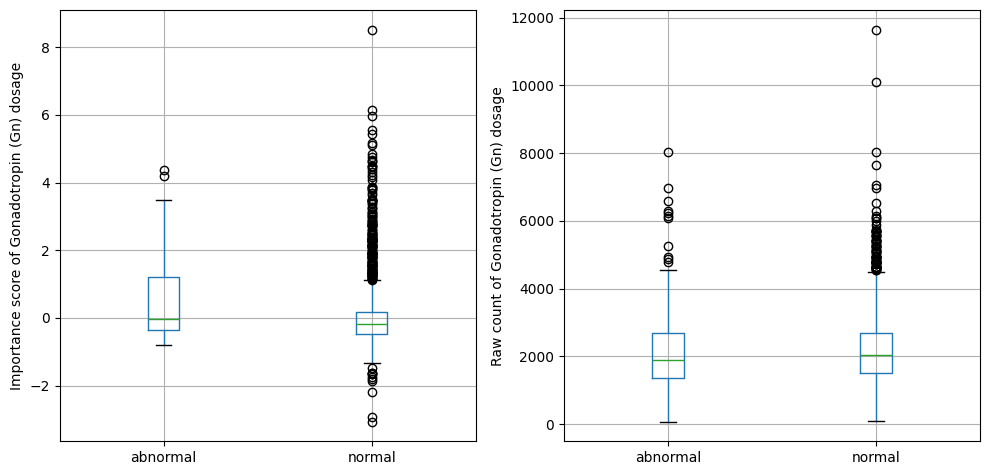

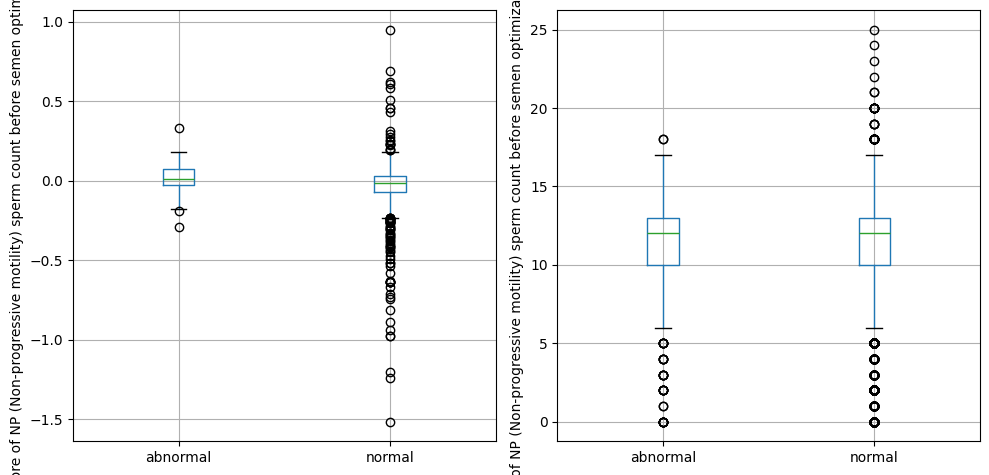

In [5]:
_tmp = test_result.T.sort_values(by=0)
_tmp = _tmp[_tmp[0] < 0.01]
for _index in _tmp.index:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    result.boxplot(column=[_index], by="targets", ax=axes[0])
    data.boxplot(column=[_index], by="Normal fertilization", ax=axes[1])

    plt.suptitle('')
    axes[0].set_title('')
    axes[0].set_xlabel('')
    axes[0].set_ylabel("Importance score of {}".format(_index))
    axes[1].set_title('')
    axes[1].set_xlabel('')
    axes[1].set_ylabel("Raw count of {}".format(_index))
    plt.tight_layout()
    plt.show()